In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

In [27]:
df = pd.read_csv("groundwater_cleaned.csv")

df.head()
df.info

<bound method DataFrame.info of                                       site  year    ph  odour  turbidity  \
0       Karan Lake (Site 1) (Ground Water)  2016  7.50    NaN       0.40   
1       Karan Lake (Site 1) (Ground Water)  2017  7.70    NaN       0.50   
2       Karan Lake (Site 1) (Ground Water)  2018  7.90    NaN       0.60   
3   Brahma Sarovar(Site 2) (Ground Water )  2016  7.61    NaN       0.20   
4   Brahma Sarovar(Site 2) (Ground Water )  2017  7.60    NaN       0.21   
5   Brahma Sarovar(Site 2) (Ground Water )  2018  7.70    NaN       0.30   
6       Teekar Taal(Site 3) (Ground Water)  2016  7.50    NaN       0.20   
7       Teekar Taal(Site 3) (Ground Water)  2017  7.53    NaN       0.30   
8       Teekar Taal(Site 3) (Ground Water)  2018  7.60    NaN       0.30   
9        Agra Canal(Site 1) (Ground Water)  2016  7.20    NaN       0.50   
10       Agra Canal(Site 1) (Ground Water)  2017  7.40    NaN       0.60   
11       Agra Canal(Site 1) (Ground Water)  2018  7.40  

In [29]:
df = pd.read_csv("gw_sanity.csv")
df.head(2)

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l)
0,Karan Lake (Site 1) (Ground Water),2016,7.5,NaN,0.4,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN
1,Karan Lake (Site 1) (Ground Water),2017,7.7,NaN,0.5,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN


In [30]:
param_map={
    'ph':'ph',
    'turbidity':'turbidity',
    'chloride':'chloride_(ppm)',
    'sulphate':'sulphates(ppm)',
    'nitrate':'nitrate(ppm)',
    'iron':'iron_(ppm)',
    'fluoride':'fluorides(ppm)',
    'conductivity':'conductiv'
}

def compute_bis_wqi(df):

    bis_limits= {
        "ph":(6.5,8.5),
        "turbidity":5,
        "chloride":250,
        "sulphate":200,
        "nitrate":45,
        "fluoride":1.5,
        "iron":0.3,
        "conductivity":2000
    }

    weights = {k:1/v if not isinstance(v,tuple) else 1/v[1]
               for k,v in bis_limits.items()}

    wqi_vals=[]

    for _,row in df.iterrows():

        num=0
        den=0

        for p,limit in bis_limits.items():

            col=param_map[p]

            if col not in df.columns or pd.isna(row[col]):
                continue

            wi=weights[p]

            if p=='ph':
                qi=abs(row[col]-7.0)/(8.5-7.0)*100
            else:
                qi=(row[col]/limit)*100

            num+=wi*qi
            den+=wi

        wqi_vals.append(num/den if den!=0 else np.nan)

    df["wqi"]=wqi_vals

    return df

In [31]:
df = compute_bis_wqi(df)

df.head()

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),...,do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l),wqi
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.40,246.0,112.4,65.0,0.4,23.0,...,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN,122.896707
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.50,276.0,122.0,76.0,0.5,23.5,...,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN,153.618156
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.60,296.0,129.9,93.0,0.6,24.8,...,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN,184.342939
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.20,294.0,121.9,60.0,0.5,31.3,...,7.2,NaN,0.3,45.0,NaN,NaN,800,NaN,NaN,153.089656
4,Brahma Sarovar(Site 2) (Ground Water ),2017,7.60,NaN,0.21,300.0,121.8,60.0,0.7,34.2,...,6.2,NaN,0.3,51.0,NaN,NaN,900,NaN,NaN,213.509994


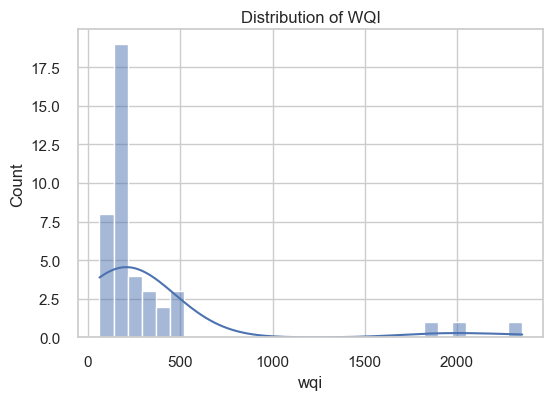

In [33]:
#EXPLORATORY DATA ANALYSIS(EDA): WQI Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["wqi"], bins=30, kde=True)
plt.title("Distribution of WQI")
plt.show()

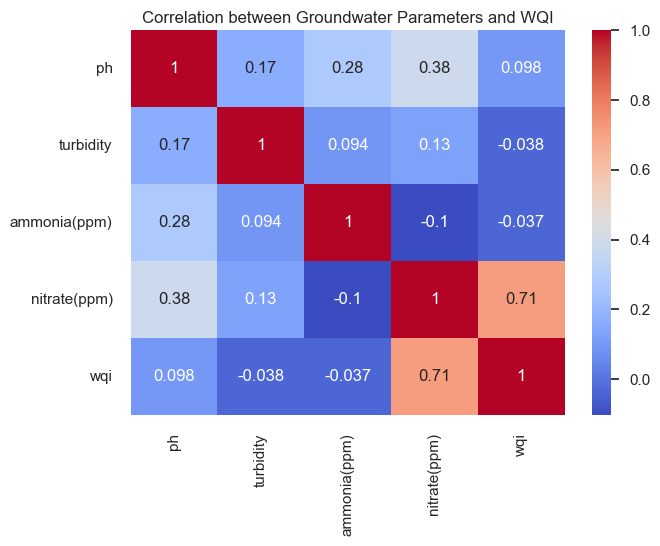

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

params = ['ph', 'turbidity', 'ammonia(ppm)', 'nitrate(ppm)', 'wqi']

df_wqi= clean.copy()
df_wqi= compute_bis_wqi(df_wqi)

corr_df = df_wqi[params].apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Groundwater Parameters and WQI")
plt.show()

In [80]:
print(df.dtypes)

site                               object
year                                int64
ph                                float64
odour                             float64
turbidity                         float64
conductivity                      float64
chloride_(ppm)                    float64
sulphates(ppm)                    float64
iron_(ppm)                        float64
cod(ppm)                          float64
bod(ppm)                          float64
do(ppm)                           float64
lead(ppm)                         float64
ammonia(ppm)                      float64
nitrate(ppm)                      float64
fluorides(ppm)                    float64
phosphates(ppm)                   float64
total_bacterial_count_(cfu/ml)      int64
total_fungal_count_(cfu/ml)       float64
pesticide_(µg/l)                  float64
wqi                               float64
dtype: object


In [81]:
print(X.shape)
print(X.isna().sum())

(42, 19)
year                               0
ph                                 0
odour                             42
turbidity                          0
conductivity                       0
chloride_(ppm)                     0
sulphates(ppm)                     0
iron_(ppm)                         0
cod(ppm)                           0
bod(ppm)                           0
do(ppm)                            0
lead(ppm)                         42
ammonia(ppm)                       0
nitrate(ppm)                       0
fluorides(ppm)                    27
phosphates(ppm)                   36
total_bacterial_count_(cfu/ml)     0
total_fungal_count_(cfu/ml)       18
pesticide_(µg/l)                  42
dtype: int64


In [117]:
#FEATURE SELECTION : Drop target and non-numerical columns.

X = df.select_dtypes(include="number").drop(columns=["wqi"])
y = df["wqi"]

In [118]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [119]:
#HANDLING MISSING VALUES
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [120]:
#SCALING: needed for SVR
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [121]:
#MODEL TRAINING
models = {
    "Random Forest":RandomForestRegressor(random_state=42),

    "Gradient Boosting":GradientBoostingRegressor(random_state=42),

    #"SVM":SVR(),
    "SVM": SVR(kernel="rbf", C=100, gamma=0.1),

    "Decision Tree":DecisionTreeRegressor(random_state=42),

    "XGBoost":XGBRegressor(random_state=42,verbosity=0)
}

In [122]:
#define NSE: NSE is widely used in hydrological modeling
def nse(y_true, y_pred):

    return 1 - (
        np.sum((y_true - y_pred) ** 2) /
        np.sum((y_true - np.mean(y_true)) ** 2)
    )

In [123]:
#Train Models + Metrics
results = []
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mae = mean_absolute_error(y_test, y_pred)

    nse_val = nse(y_test, y_pred)

    results.append([name, r2, rmse, mae, nse_val])

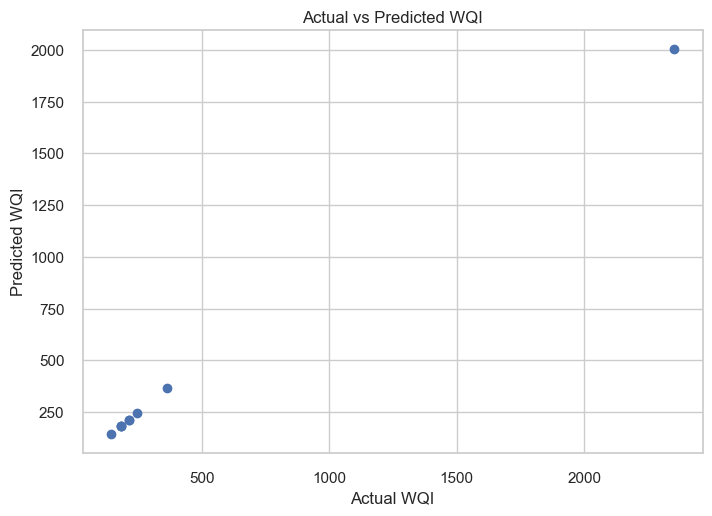

In [124]:
#Residual Analysis
plt.scatter(y_test, y_pred)
plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")

plt.title("Actual vs Predicted WQI")
plt.show()

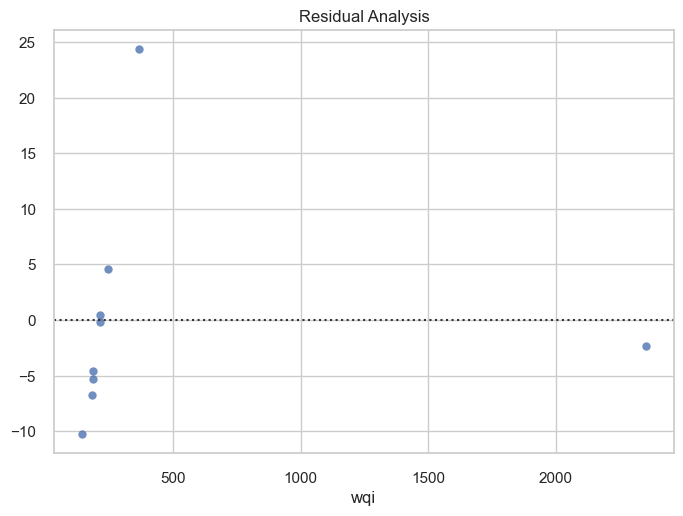

In [125]:
#BETTER VERSION OF RESIDUAL ANALYSIS
sns.residplot(x=y_test, y=y_pred)
plt.title("Residual Analysis")
plt.show()

In [126]:
X.isna().sum()

year                               0
ph                                 0
odour                             42
turbidity                          0
conductivity                       0
chloride_(ppm)                     0
sulphates(ppm)                     0
iron_(ppm)                         0
cod(ppm)                           0
bod(ppm)                           0
do(ppm)                            0
lead(ppm)                         42
ammonia(ppm)                       0
nitrate(ppm)                       0
fluorides(ppm)                    27
phosphates(ppm)                   36
total_bacterial_count_(cfu/ml)     0
total_fungal_count_(cfu/ml)       18
pesticide_(µg/l)                  42
dtype: int64

In [127]:
# K FOLD CROSS VALIDATION
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

In [136]:
final_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mae = mean_absolute_error(y_test, y_pred)

    nse_val = nse(y_test, y_pred)

    cv5 = cross_val_score(model, X_train, y_train, cv=kf5, scoring="r2")

    cv10 = cross_val_score(model, X_train, y_train, cv=kf10, scoring="r2")
    

    final_results.append([
        name,
        r2,
        rmse,
        mae,
        nse_val,
        f"{cv5.mean():.3f} ± {cv5.std():.3f}",
        f"{cv10.mean():.3f} ± {cv10.std():.3f}"
    ])

In [130]:
columns = [
"Model",
"R²",
"RMSE",
"MAE",
"NSE",
"5 Fold R²",
"10 Fold R²"
]

results_df = pd.DataFrame(final_results, columns=columns)

results_df.sort_values(by="R²", ascending=False)

,Model,R²,RMSE,MAE,NSE,5 Fold R²,10 Fold R²
4,XGBoost,0.970117,116.621974,39.443728,0.970117,-11.814 ± 15.685,-10.098 ± 22.704
3,Decision Tree,0.939829,165.486320,59.822063,0.939829,-12.963 ± 18.040,-2.407 ± 9.825
1,Gradient Boosting,0.900741,212.546766,79.186979,0.900741,0.394 ± 0.619,0.586 ± 0.735
0,Random Forest,0.808235,295.429972,117.836586,0.808235,0.259 ± 0.509,0.403 ± 0.876
2,SVM,0.029002,664.781725,248.937960,0.029002,0.313 ± 0.579,-0.246 ± 1.875


In [115]:
corr = df.select_dtypes(include="number").corr()

corr["wqi"].sort_values(ascending=False)

wqi                               1.000000
iron_(ppm)                        0.999752
nitrate(ppm)                      0.711726
phosphates(ppm)                   0.645067
total_fungal_count_(cfu/ml)       0.596375
conductivity                      0.267546
bod(ppm)                          0.246376
ph                                0.098181
year                              0.023190
do(ppm)                          -0.007466
ammonia(ppm)                     -0.037079
turbidity                        -0.037521
total_bacterial_count_(cfu/ml)   -0.157751
chloride_(ppm)                   -0.327930
fluorides(ppm)                   -0.419395
cod(ppm)                         -0.458416
sulphates(ppm)                   -0.516904
odour                                  NaN
lead(ppm)                              NaN
pesticide_(µg/l)                       NaN
Name: wqi, dtype: float64

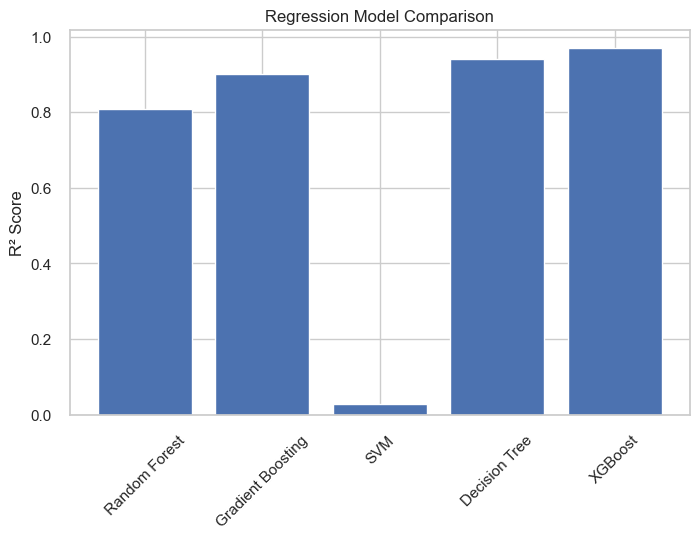

In [131]:
#MODEL COMPARISON PLOT
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R²"])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Regression Model Comparison")
plt.show()

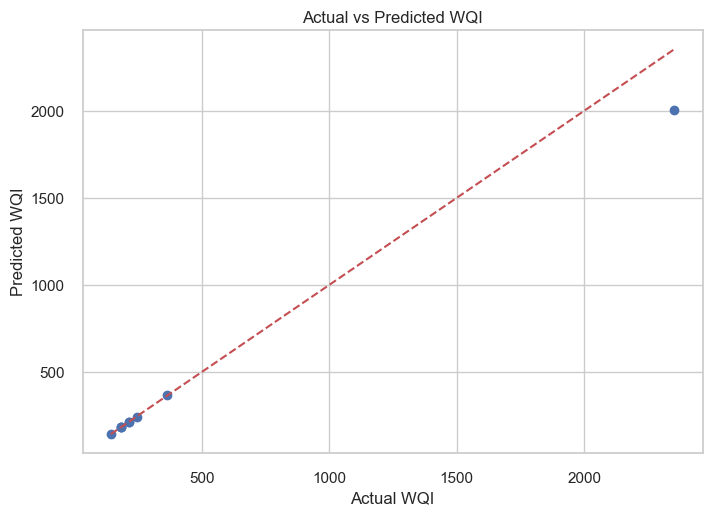

In [132]:
#ACTUAL VS PREDICTED PLOT
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted WQI")
plt.show()

In [133]:
df.shape

(42, 21)

In [137]:
#SHAP ANALYSIS
import shap
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

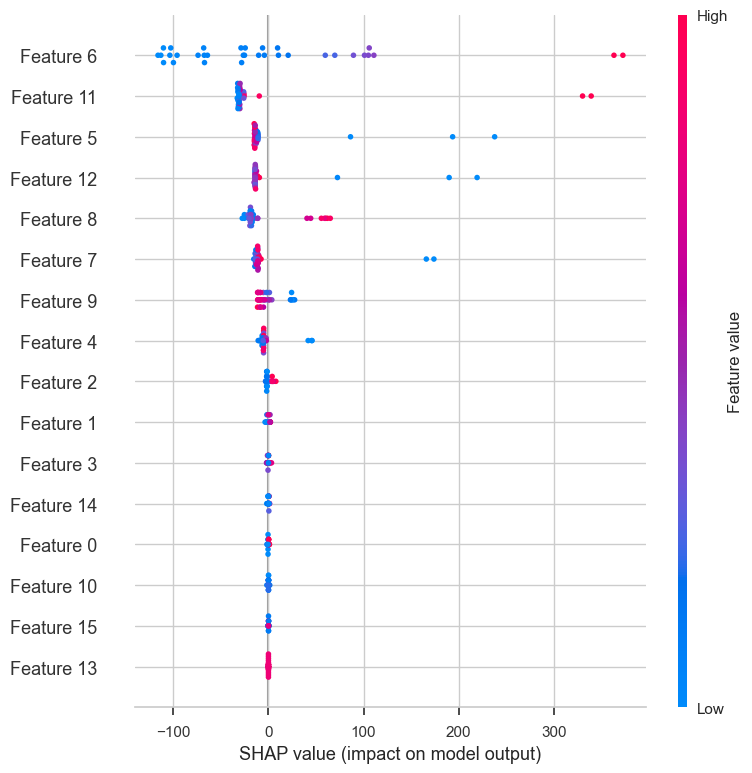

In [139]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)
#PLOT
shap.summary_plot(shap_values, X_train)